In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset (2).csv')

# Display the first 5 rows
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [2]:
# Check the number of rows and columns
print("Dataset Shape:", df.shape)

# Display column names
print("\nColumn Names:")
print(df.columns.tolist())

# Check data types
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (4000, 28)

Column Names:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Data Types:
Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                    

In [3]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

# Check duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

Missing Values:
Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      48
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                40
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                  32
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3     0
Disease_Pest

In [4]:
# Make a copy of the original dataset
df_clean = df.copy()

# Fill missing values using the median
df_clean['Rainfall_mm'] = df_clean['Rainfall_mm'].fillna(
    df_clean['Rainfall_mm'].median()
)

df_clean['Soil_Moisture_pct'] = df_clean['Soil_Moisture_pct'].fillna(
    df_clean['Soil_Moisture_pct'].median()
)

df_clean['Yield_Tonnes_Ha'] = df_clean['Yield_Tonnes_Ha'].fillna(
    df_clean['Yield_Tonnes_Ha'].median()
)

# Check missing values again
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nDataset shape after cleaning:", df_clean.shape)

Missing values after cleaning:
Farm_ID                          0
State                            0
District                         0
Crop                             0
Season                           0
Farm_Area_Hectares               0
Rainfall_mm                      0
Avg_Temperature_C                0
Humidity_pct                     0
Sunlight_Hours_Day               0
Soil_pH                          0
Soil_Moisture_pct                0
Nitrogen_kg_ha                   0
Phosphorus_kg_ha                 0
Potassium_kg_ha                  0
Irrigation_Method                0
Fertilizer_kg_ha                 0
Pesticide_Litre_ha               0
Seed_Quality_Score               0
Yield_Tonnes_Ha                  0
Production_Tonnes                0
Market_Price_INR_Tonne           0
Total_Cost_INR                   0
Revenue_INR                      0
Profit_INR                       0
Water_Used_m3                    0
Water_Efficiency_t_per_1000m3    0
Disease_Pest_Risk_pct   

In [5]:
# Check the seasons in the dataset
print("Seasons:")
print(df_clean['Season'].value_counts())

Seasons:
Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64


In [6]:
# Basic statistics for important agricultural performance measures
season_summary = df_clean.groupby('Season')[
    ['Yield_Tonnes_Ha', 'Production_Tonnes', 'Revenue_INR',
     'Profit_INR', 'Water_Used_m3', 'Disease_Pest_Risk_pct']
].mean()

season_summary

,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Disease_Pest_Risk_pct
Season,,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,6102.201237,54.467903
Rabi,5.039435,41.486712,601526.048556,87689.470191,5846.987093,40.482114
Zaid,4.641313,38.886111,519171.904040,-24804.824916,6419.893939,38.216667


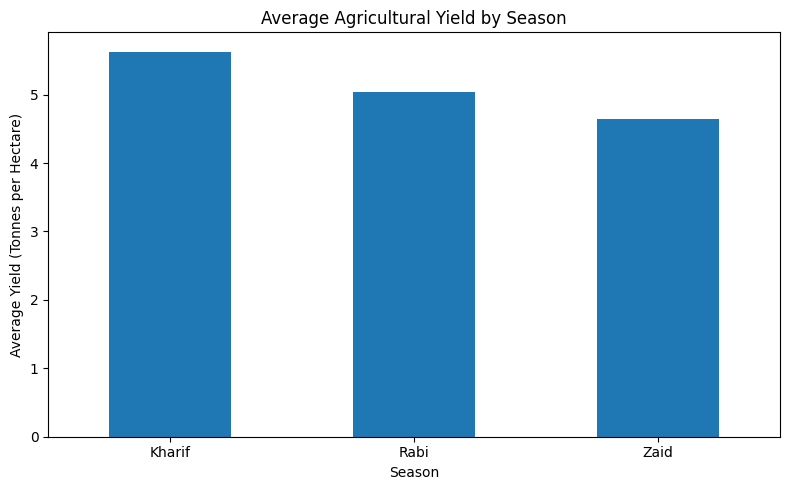

In [7]:
# Average yield by season

yield_by_season = df_clean.groupby('Season')['Yield_Tonnes_Ha'].mean()

plt.figure(figsize=(8, 5))

yield_by_season.plot(kind='bar')

plt.title('Average Agricultural Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes per Hectare)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

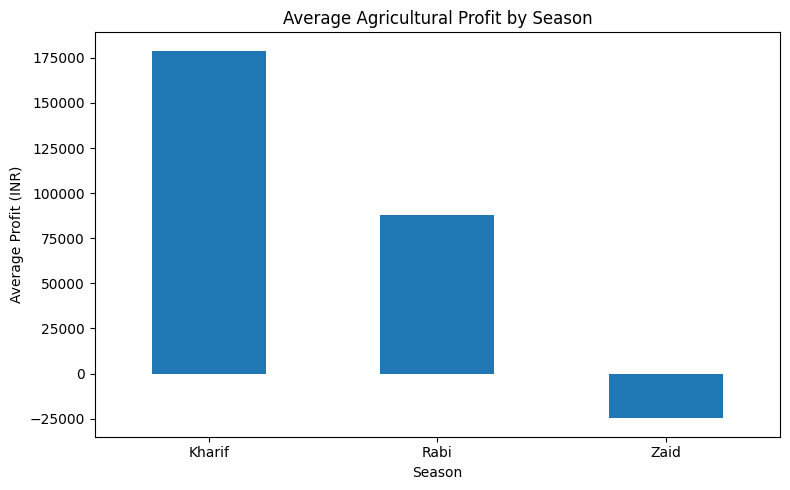

In [8]:
# Average profit by season

profit_by_season = df_clean.groupby('Season')['Profit_INR'].mean()

plt.figure(figsize=(8, 5))

profit_by_season.plot(kind='bar')

plt.title('Average Agricultural Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [9]:
# Average yield by crop

crop_yield = df_clean.groupby('Crop')['Yield_Tonnes_Ha'].mean().sort_values(ascending=False)

print("Average Yield by Crop:")
print(crop_yield)

Average Yield by Crop:
Crop
Sugarcane    46.642361
Maize         2.710036
Rice          2.431304
Wheat         2.108013
Chilli        1.542767
Groundnut     1.322901
Cotton        1.229783
Pulses        0.921512
Name: Yield_Tonnes_Ha, dtype: float64


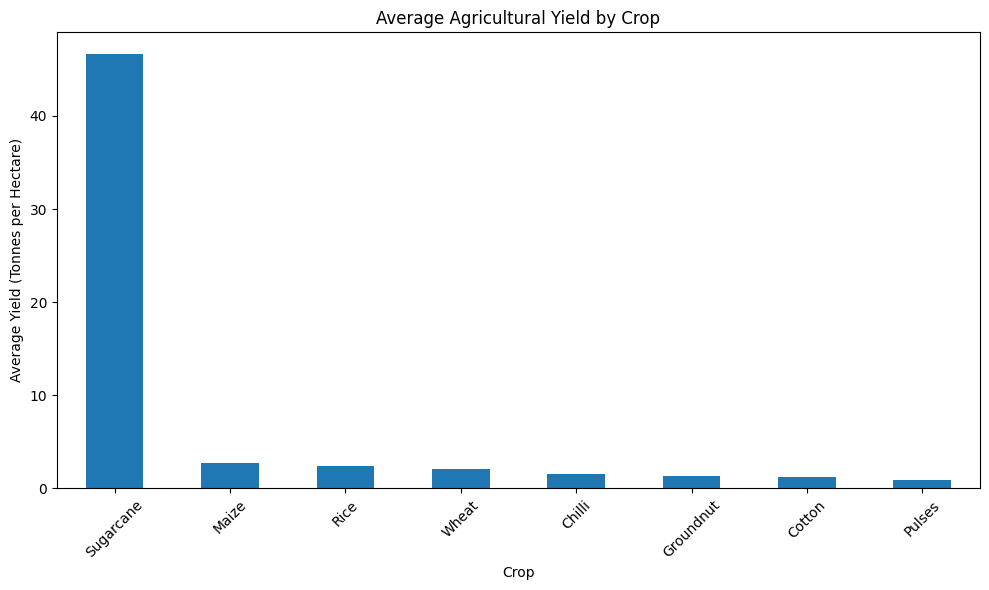

In [10]:
# Visualize average yield by crop

plt.figure(figsize=(10, 6))

crop_yield.plot(kind='bar')

plt.title('Average Agricultural Yield by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes per Hectare)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [11]:
# Average yield by crop and season

crop_season_yield = df_clean.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print("Average Yield by Crop and Season:")
display(crop_season_yield)

Average Yield by Crop and Season:


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


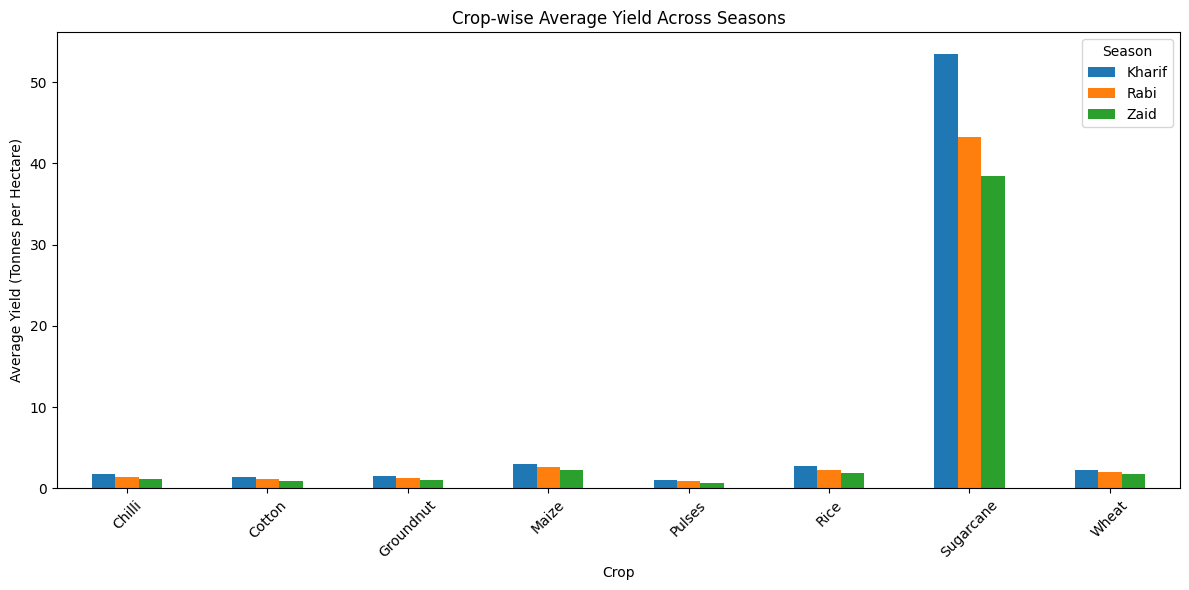

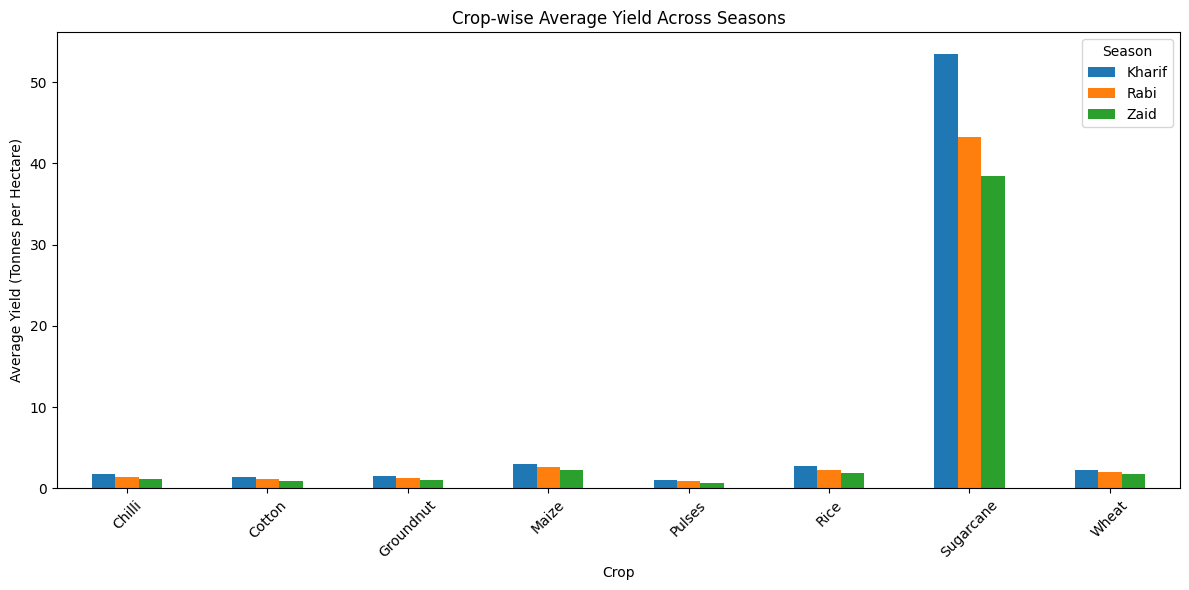

In [12]:
# Crop-wise seasonal yield comparison

crop_season_yield.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Crop-wise Average Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes per Hectare)')
plt.xticks(rotation=45)

plt.legend(title='Season')
plt.tight_layout()
plt.show()# Crop-wise seasonal yield comparison

crop_season_yield.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Crop-wise Average Yield Across Seasons')
plt.xlabel('Crop')
plt.ylabel('Average Yield (Tonnes per Hectare)')
plt.xticks(rotation=45)

plt.legend(title='Season')
plt.tight_layout()
plt.show()

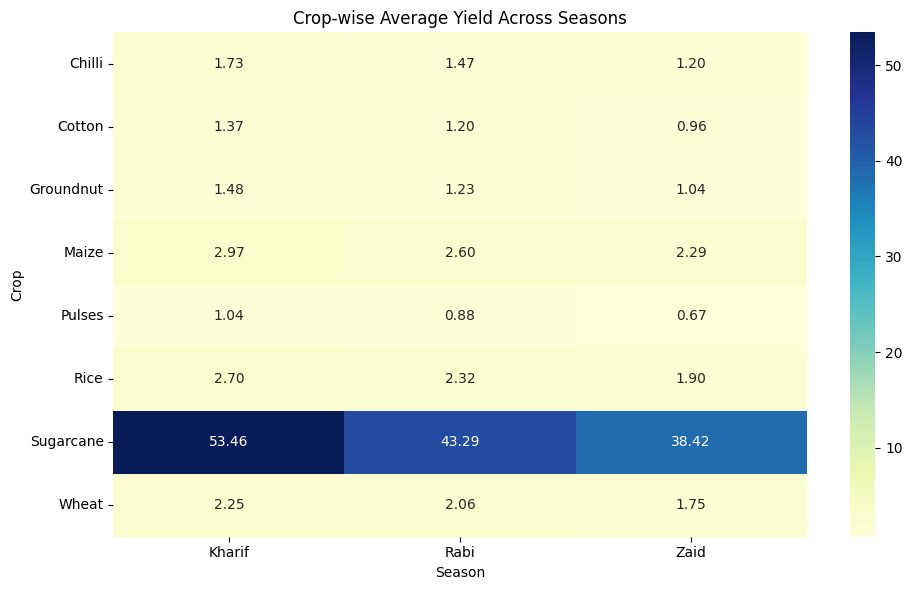

In [13]:
import seaborn as sns

# Create a heatmap of crop-wise yield across seasons

plt.figure(figsize=(10, 6))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Crop-wise Average Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.tight_layout()
plt.show()

In [14]:
# Environmental conditions by season

environment_summary = df_clean.groupby('Season')[
    ['Rainfall_mm',
     'Avg_Temperature_C',
     'Humidity_pct',
     'Soil_Moisture_pct',
     'Sunlight_Hours_Day']
].mean()

environment_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Soil_Moisture_pct,Sunlight_Hours_Day
Season,,,,,
Kharif,849.199663,28.454019,71.812591,31.149859,6.793367
Rabi,437.615366,23.489183,57.893178,24.069392,7.589797
Zaid,304.654714,31.042088,52.012121,19.279630,8.178788


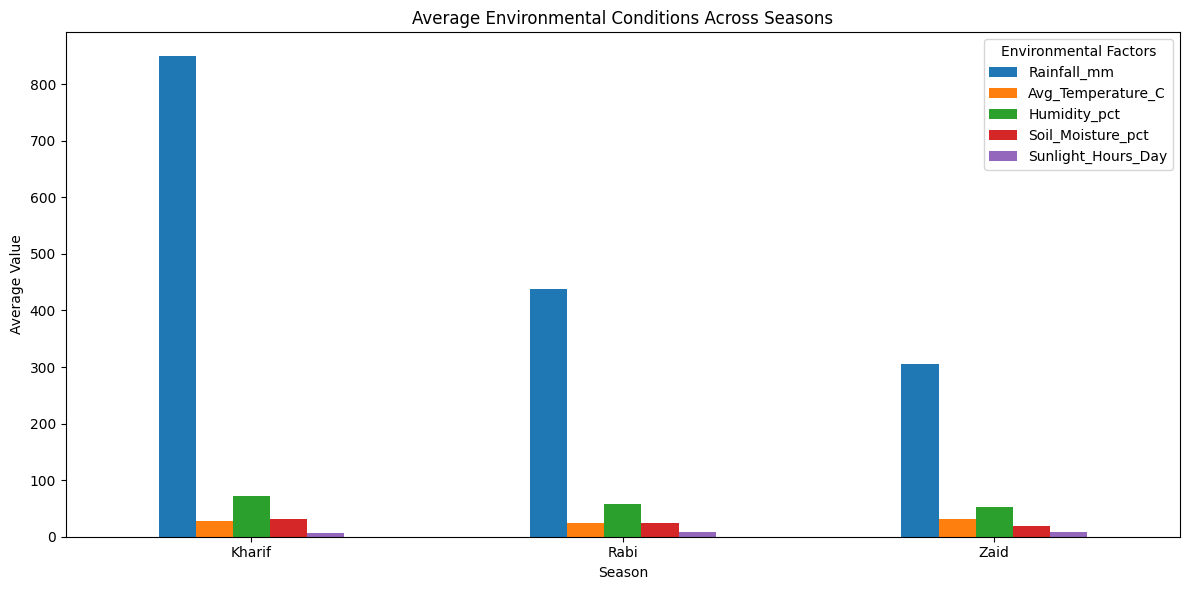

In [15]:
# Visualize environmental conditions across seasons

environment_summary.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Average Environmental Conditions Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Value')
plt.xticks(rotation=0)

plt.legend(title='Environmental Factors')
plt.tight_layout()
plt.show()

In [16]:
# Water usage and efficiency by season

water_summary = df_clean.groupby('Season')[
    ['Water_Used_m3', 'Water_Efficiency_t_per_1000m3']
].mean()

water_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3
Season,,
Kharif,6102.201237,5.891834
Rabi,5846.987093,5.186122
Zaid,6419.893939,4.413239


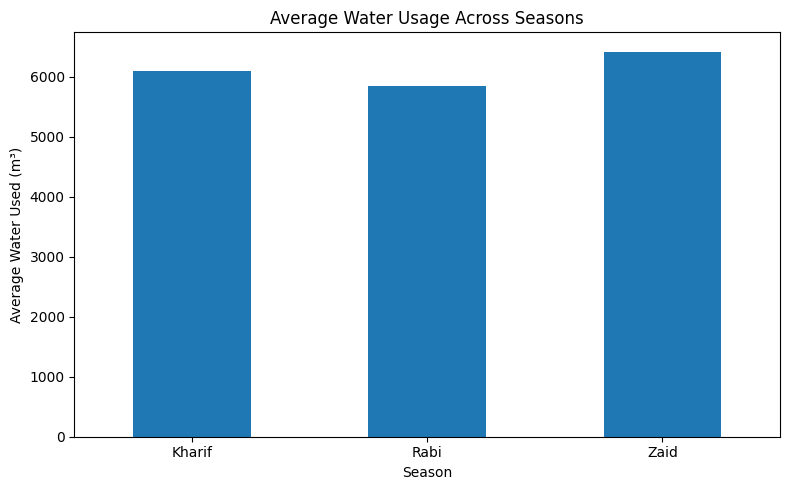

In [17]:
# Water usage by season

plt.figure(figsize=(8, 5))

water_summary['Water_Used_m3'].plot(kind='bar')

plt.title('Average Water Usage Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Water Used (m³)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

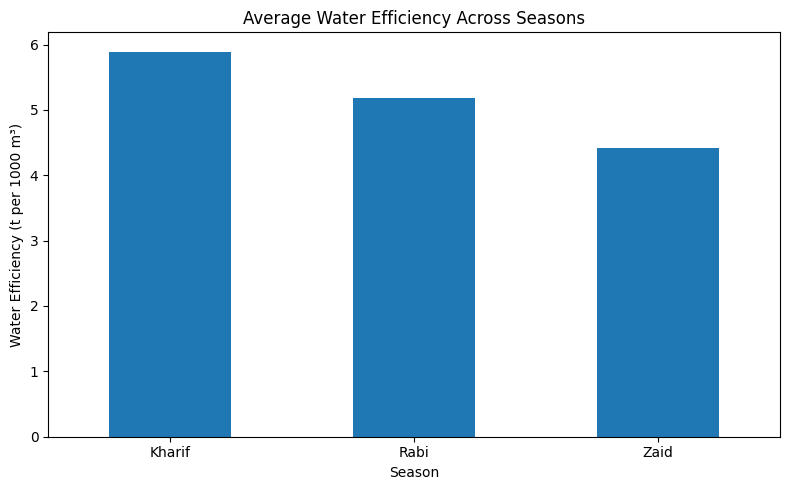

In [18]:
# Water efficiency by season

plt.figure(figsize=(8, 5))

water_summary['Water_Efficiency_t_per_1000m3'].plot(kind='bar')

plt.title('Average Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (t per 1000 m³)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Disease and pest risk by season

risk_by_season = df_clean.groupby('Season')['Disease_Pest_Risk_pct'].mean()

print("Average Disease/Pest Risk by Season:")
print(risk_by_season)

Average Disease/Pest Risk by Season:
Season
Kharif    54.467903
Rabi      40.482114
Zaid      38.216667
Name: Disease_Pest_Risk_pct, dtype: float64


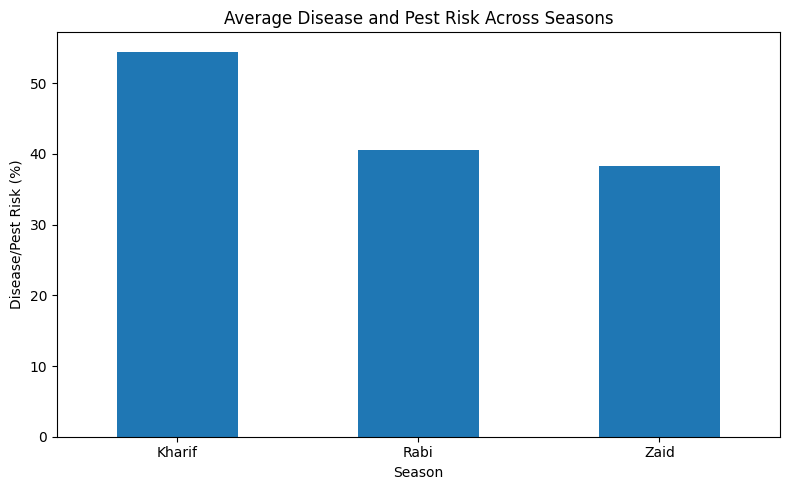

In [20]:
# Visualize disease and pest risk

plt.figure(figsize=(8, 5))

risk_by_season.plot(kind='bar')

plt.title('Average Disease and Pest Risk Across Seasons')
plt.xlabel('Season')
plt.ylabel('Disease/Pest Risk (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [21]:
# Economic performance by season

economic_summary = df_clean.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].mean()

economic_summary

,Total_Cost_INR,Revenue_INR,Profit_INR
Season,,,
Kharif,531804.408094,710719.055649,178914.647555
Rabi,513836.578365,601526.048556,87689.470191
Zaid,543976.728956,519171.904040,-24804.824916


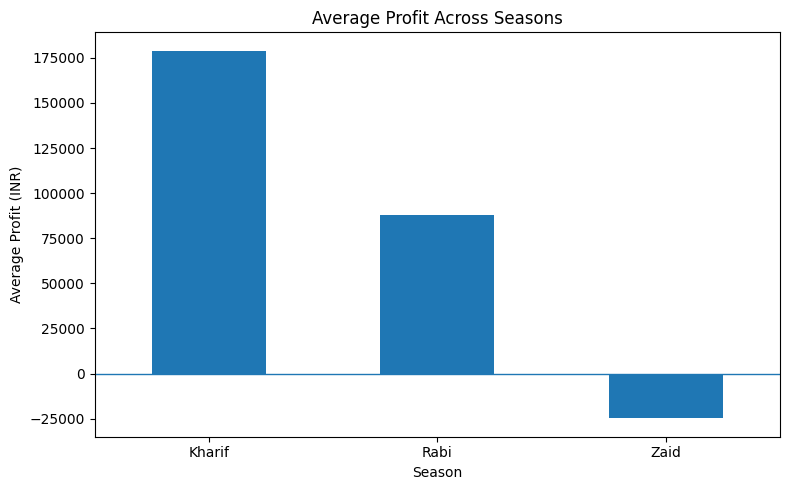

In [22]:
# Average profit by season

plt.figure(figsize=(8, 5))

economic_summary['Profit_INR'].plot(kind='bar')

plt.title('Average Profit Across Seasons')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.axhline(y=0, linewidth=1)

plt.tight_layout()
plt.show()

In [23]:
correlation_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Soil_Moisture_pct',
    'Sunlight_Hours_Day',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Water_Used_m3',
    'Disease_Pest_Risk_pct',
    'Yield_Tonnes_Ha',
    'Revenue_INR',
    'Profit_INR'
]

correlation_matrix = df_clean[correlation_columns].corr()

print("Correlation with Yield:")
print(correlation_matrix['Yield_Tonnes_Ha'].sort_values(ascending=False))

Correlation with Yield:
Yield_Tonnes_Ha          1.000000
Profit_INR               0.488466
Revenue_INR              0.432152
Water_Used_m3            0.386294
Rainfall_mm              0.030951
Disease_Pest_Risk_pct    0.014292
Humidity_pct             0.012297
Soil_Moisture_pct        0.010999
Avg_Temperature_C        0.009996
Fertilizer_kg_ha         0.000018
Pesticide_Litre_ha      -0.007779
Sunlight_Hours_Day      -0.015341
Name: Yield_Tonnes_Ha, dtype: float64


In [24]:
season_performance = df_clean.groupby('Season')[
    [
        'Yield_Tonnes_Ha',
        'Production_Tonnes',
        'Revenue_INR',
        'Profit_INR',
        'Water_Used_m3',
        'Water_Efficiency_t_per_1000m3',
        'Disease_Pest_Risk_pct'
    ]
].mean()

season_performance


,Yield_Tonnes_Ha,Production_Tonnes,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,5.628612,46.311192,710719.055649,178914.647555,6102.201237,5.891834,54.467903
Rabi,5.039435,41.486712,601526.048556,87689.470191,5846.987093,5.186122,40.482114
Zaid,4.641313,38.886111,519171.904040,-24804.824916,6419.893939,4.413239,38.216667


In [25]:
print("Season Performance Summary")
print(season_performance.round(2))

Season Performance Summary
        Yield_Tonnes_Ha  Production_Tonnes  Revenue_INR  Profit_INR  \
Season                                                                
Kharif             5.63              46.31    710719.06   178914.65   
Rabi               5.04              41.49    601526.05    87689.47   
Zaid               4.64              38.89    519171.90   -24804.82   

        Water_Used_m3  Water_Efficiency_t_per_1000m3  Disease_Pest_Risk_pct  
Season                                                                       
Kharif        6102.20                           5.89                  54.47  
Rabi          5846.99                           5.19                  40.48  
Zaid          6419.89                           4.41                  38.22  


In [26]:
Q1 = df_clean['Profit_INR'].quantile(0.25)
Q3 = df_clean['Profit_INR'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

profit_outliers = df_clean[
    (df_clean['Profit_INR'] < lower_bound) |
    (df_clean['Profit_INR'] > upper_bound)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of unusual profit observations:", len(profit_outliers))

Q1: -148731.75
Q3: 216187.75
IQR: 364919.5
Lower Bound: -696111.0
Upper Bound: 763567.0
Number of unusual profit observations: 404


In [27]:
print(profit_outliers[
    ['Farm_ID', 'State', 'District', 'Crop', 'Season',
     'Yield_Tonnes_Ha', 'Revenue_INR', 'Total_Cost_INR', 'Profit_INR']
].head(10))

     Farm_ID           State  District       Crop  Season  Yield_Tonnes_Ha  \
9    SF10010      Tamil Nadu   Raichur     Chilli    Rabi             2.29   
30   SF10031       Telangana  Nalgonda     Chilli    Rabi             1.51   
61   SF10062       Karnataka  Ludhiana     Cotton    Rabi             1.80   
75   SF10076     Maharashtra    Guntur  Sugarcane  Kharif            62.58   
78   SF10079  Madhya Pradesh  Nalgonda     Chilli    Rabi             2.18   
87   SF10088  Madhya Pradesh  Warangal     Chilli  Kharif             1.98   
88   SF10089  Andhra Pradesh   Raichur     Chilli  Kharif             2.19   
92   SF10093         Gujarat    Guntur  Sugarcane  Kharif            70.23   
104  SF10105         Gujarat   Krishna      Wheat    Zaid             0.30   
110  SF10111     Maharashtra  Ludhiana     Pulses  Kharif             1.73   

     Revenue_INR  Total_Cost_INR  Profit_INR  
9        2958907         1004072     1954835  
30       1846075          738746     1107329  


In [28]:
# Compare Kharif and Zaid performance

kharif = season_performance.loc['Kharif']
zaid = season_performance.loc['Zaid']

yield_difference = ((kharif['Yield_Tonnes_Ha'] - zaid['Yield_Tonnes_Ha']) /
                    zaid['Yield_Tonnes_Ha']) * 100

profit_difference = ((kharif['Profit_INR'] - zaid['Profit_INR']) /
                     abs(zaid['Profit_INR'])) * 100

water_efficiency_difference = (
    (kharif['Water_Efficiency_t_per_1000m3'] -
     zaid['Water_Efficiency_t_per_1000m3']) /
    zaid['Water_Efficiency_t_per_1000m3']
) * 100

print(f"Kharif yield is {yield_difference:.2f}% higher than Zaid.")
print(f"Difference in profit between Kharif and Zaid: ₹{kharif['Profit_INR'] - zaid['Profit_INR']:.2f}")
print(f"Kharif water efficiency is {water_efficiency_difference:.2f}% higher than Zaid.")

Kharif yield is 21.27% higher than Zaid.
Difference in profit between Kharif and Zaid: ₹203719.47
Kharif water efficiency is 33.50% higher than Zaid.
